In [1]:
%load_ext autoreload
%autoreload 2

import jax
jax.config.update("jax_enable_x64", True)

from mGST.low_level_jit import cost_function_jax_mps
from mGST.utility_functions_comparisons import GSTConfiguration, get_full_mgst_parameters_from_configuration, get_compressed_rep_from_mgst_output, get_initial_gate_set_for_optimization, get_isometry_dimensions_from_tensor

from mGST.trust_region import riemannian_hessian_vector_fn, riemannian_gradient_fn, truncated_conjugate_gradient, run_trust_region_optimization, run_riemannian_optimization
from mGST.trust_region_linearized import rhessian_vector_product_from_linear_map
from mGST.trust_region_linearized import riemannian_and_euclidean_gradient_fn as new_riemannian_gradient_fn
# from mGST.trust_region_linearized import truncated_conjugate_gradient as new_truncated_conjugate_gradient
from mGST.automatic_diff import hvp, automatic_gradient
from mGST.typing import OperatorSchedule, TrustRegionOptions
from mGST.visualization import plot_cost_function

import jax.numpy as jnp

backend = "iqmfakeapollo"

/Users/emiliano.godinez/.pyenv/versions/qcvv-env/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Manual check for linearize

In [2]:
# First using the JAX compilation with smaller qubits to see if this helps
dim_1q = 2
num_circuits_1q = 100
shots = 1000
kraus_rank = 4

Q1_GST = GSTConfiguration(
    qubit_layouts=[[0]],
    gate_set="1QXYI",
    num_circuits=num_circuits_1q,
    shots=shots,
    rank=kraus_rank,
)

kraus_tensor_mgst_1q, kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, prob_matrix_1q, indices_list_1q = get_full_mgst_parameters_from_configuration(
    Q1_GST, backend, only_jax_variables=True
)

kraus_tensor_1q_target, povm_psd_1q_target, state_psd_1q_target = get_compressed_rep_from_mgst_output(kraus_mgst_1q, povm_mgst_1q, state_mgst_1q, kraus_rank=kraus_rank, state_rank=dim_1q, povm_rank=dim_1q)


2026-09-14 14:07:14,258 - iqm.benchmarks.logging_config - INFO - Generating 100 random GST circuits
2026-09-14 14:07:14,460 - iqm.benchmarks.logging_config - INFO - Will transpile all 100 circuits according to fixed physical layout
2026-09-14 14:07:14,617 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-09-14 14:07:15,125 - iqm.benchmarks.logging_config - INFO - Submitting batch with 100 circuits corresponding to qubits [0]
2026-09-14 14:07:15,133 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-09-14 14:07:15,187 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-09-14 14:07:15,375 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-09-14 14:07:15,524 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-09-14 14:07:15,636 - iqm.benchmarks.logging_config - INFO - Run completed


In [3]:
input_1q = {
    "kraus_tensor": kraus_tensor_1q_target,
    "povm_psd": povm_psd_1q_target,
    "state_psd": state_psd_1q_target,
    "prob_matrix": prob_matrix_1q,
    "indices_list": indices_list_1q,
    "jit": True,
}

input_no_kraus = {
    "povm_psd": povm_psd_1q_target,
    "state_psd": state_psd_1q_target,
    "prob_matrix": prob_matrix_1q,
    "indices_list": indices_list_1q,
    "jit": True,
}

In [4]:
num_qubits = 1
dim = 2 ** num_qubits
state_rank = dim # max
povm_rank = dim # max

target_gate_set_superops = {
    "kraus": kraus_mgst_1q,
    "povm": povm_mgst_1q,
    "state": state_mgst_1q
}


# 2. Initiallization
init_gate_set_psd = get_initial_gate_set_for_optimization(
    target_superops=target_gate_set_superops,
    kraus_rank=kraus_rank,
    state_rank=state_rank,
    povm_rank=povm_rank
)

cost_fn_kwargs = {
    "indices_list": indices_list_1q,
    "prob_matrix": prob_matrix_1q,
    "jit": True,
    "use_log_likelihood": True,
    "verbose": False,  # we don't want to print during the cost function evaluation
    "num_shots": shots,
}

In [5]:
%time cost_function_jax_mps(**input_1q)


CPU times: user 2.22 s, sys: 57.3 ms, total: 2.28 s
Wall time: 940 ms


Array(0.00201293, dtype=float64)

In [4]:
cost_fn_kraus = lambda x: cost_function_jax_mps(x, **input_no_kraus)
operator_type = "kraus"
metric = "euclidean"

In [8]:
rhessian_vector_fn = lambda x, z: riemannian_hessian_vector_fn(x=x, tangent_vector=z, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric, return_tensor=True)

x = kraus_tensor_1q_target
z = 2 * kraus_tensor_1q_target

## Timing and correctness

In [15]:
%time rhessian_vector_fn(x, z)

CPU times: user 11.2 s, sys: 377 ms, total: 11.6 s
Wall time: 5.29 s


Array([[[[-2.46384569e-01+2.30311705e-01j,
           1.90324232e+00+2.81550561e-01j],
         [-1.90451347e+00+3.96423494e-01j,
          -1.69089086e-01-2.26128176e-01j]],

        [[ 5.01144359e-01+3.93294588e-02j,
          -1.32699049e-01+1.37315757e-01j],
         [-5.17373001e-01-6.63037186e-01j,
          -5.03723971e-01-7.49439943e-02j]],

        [[ 2.63780100e-01+4.08088987e-04j,
          -2.12693620e-01+7.37437138e-02j],
         [ 5.82231777e-01+7.75912942e-01j,
          -2.18160029e-01+4.97752852e-02j]],

        [[-5.74515792e-02+2.19779111e-02j,
          -2.43741052e-01+2.53922961e-02j],
         [ 6.34603646e-03-1.07723484e-01j,
           8.04684589e-02-3.73981156e-02j]]],


       [[[-2.10764203e-01-2.23635217e-01j,
           8.69631389e-01+3.10536584e-02j],
         [-9.04490287e-01+8.82919709e-02j,
          -2.16183596e-01+2.57484808e-01j]],

        [[ 4.62856034e-01+6.92330088e-02j,
          -2.99965578e-01-4.14965925e-01j],
         [-3.04740970e-01+2.057

In [16]:
time_rhessian_old = %timeit -o rhessian_vector_fn(x, z)

164 ms ± 1.31 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [18]:
rgradient, euclidean_gradient, linearized_map = %time linearize_riemannian_gradient(x=x, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric)

CPU times: user 6.81 s, sys: 278 ms, total: 7.08 s
Wall time: 3.38 s


In [22]:
rhessian_test = %time rhessian_vector_product_from_linear_map(x=x, delta_tensor=z, rgradient=rgradient, linearized_hvp_map=linearized_map, operator_type=operator_type, metric=metric)

CPU times: user 7.12 s, sys: 299 ms, total: 7.42 s
Wall time: 3.16 s


In [27]:
test_object = linearized_map(z)
type(test_object)

tuple

In [25]:
rhessian_og = rhessian_vector_fn(x, z)
jnp.allclose(rhessian_og, rhessian_test), jnp.linalg.norm(rhessian_og - rhessian_test)

(Array(False, dtype=bool), Array(189.43570603, dtype=float64))

In [38]:
rgrad_fn = lambda x: riemannian_gradient_fn(x=x, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric) # Riemannian gradient (from df/dx*)

rgrad_fn_new = lambda x: new_riemannian_gradient_fn(x=x, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric) # New Riemannian gradient (from df/dx*)

In [33]:
rgrad_x_tensor_og, Drgrad_x_to_z_tensor_og = hvp(function=rgrad_fn, x=x, z=z)

In [34]:
rgrad_x_tensor_new, hvp_map = jax.linearize(rgrad_fn, x)
Drgrad_x_t_z_tensor_new = hvp_map(z)

In [35]:
jnp.allclose(Drgrad_x_to_z_tensor_og, Drgrad_x_t_z_tensor_new)

Array(True, dtype=bool)

In [40]:
(rgrad_tensor_new_2, euclidean_tensor_new_2), hvp_map_2 = jax.linearize(rgrad_fn_new, x)

output_new_map = hvp_map_2(z)

In [45]:
jnp.allclose(Drgrad_x_to_z_tensor_og, output_new_map[0]), jnp.allclose(Drgrad_x_t_z_tensor_new, output_new_map[1])

(Array(True, dtype=bool), Array(False, dtype=bool))

In [46]:
time_rhessian_old = %timeit -o hvp(function=rgrad_fn, x=x, z=z)
time_rhessian_new = %timeit -o hvp_map(z)

163 ms ± 8.85 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
30.7 ms ± 437 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [47]:
time_rhessian_new_2 = %timeit -o hvp_map_2(z)

31.1 ms ± 486 μs per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [48]:
time_linearize_new = %timeit -o jax.linearize(rgrad_fn, x)
time_linearize_new_2 = %timeit -o jax.linearize(rgrad_fn_new, x)

393 ms ± 5.78 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
390 ms ± 2.19 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [92]:
print(f"{'operator':<8} {'old (best)':>14} {'new (best)':>14} {'linearization (best)':>22} {'iterations needed':>18}")
old_best = time_rhessian_old.best
new_best = time_rhessian_new.best
linearization_best = time_linearize_new_2.best
# number of iterations needed for the linearization + new best time to be better than the old best time
num_iterations_needed = int(jnp.ceil(linearization_best/(old_best - new_best)))
print(f"{operator_type:<8} {old_best * 1e3:>11.3f} ms {new_best * 1e3:>11.3f} ms {linearization_best * 1e3:>16.3f} ms {num_iterations_needed:>18}")

operator     old (best)     new (best)   linearization (best)  iterations needed
kraus        155.687 ms      30.052 ms          387.507 ms                  4


In [98]:
n = 4
old_best * n, linearization_best + n * new_best

(0.622747668006923, 0.5077143419912318)

In [56]:
n, p = get_isometry_dimensions_from_tensor(x, operator_type)

In [61]:
rgradient_new, euclidean_gradient_new, linearized_map_new = linearize_riemannian_gradient(x=x, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric)

In [66]:
# now we can test how long the whole optimization takes.
solution_old, on_boundary_old = truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, metric=metric, n=n, p=p, rhessian_vector_fn=rhessian_vector_fn, verbose=True)

TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------


In [67]:
solution_new, on_boundary_new = new_truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, operator_type=operator_type, metric=metric, n=n, p=p, linearized_hvp_map=linearized_map_new, verbose=True)

TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------


In [105]:
# can we create a rhessian vector function to work with the previous function
hacky_rhessian_vector_fn = lambda x, z: rhessian_vector_product_from_linear_map(x=x, z=z, rgradient=rgradient, operator_type=operator_type, metric=metric, linearized_hvp_map=linearized_map_new)

solution_hacky, on_boundary_hacky = truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, metric=metric, n=n, p=p, rhessian_vector_fn=hacky_rhessian_vector_fn, verbose=True)

TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------


In [107]:
jnp.allclose(solution_old, solution_new), jnp.allclose(solution_old, solution_hacky)

(Array(True, dtype=bool), Array(True, dtype=bool))

In [70]:
time_tc_old = %timeit -o truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, metric=metric, n=n, p=p, rhessian_vector_fn=rhessian_vector_fn, verbose=False)
time_tc_new = %timeit -o new_truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, operator_type=operator_type, metric=metric, n=n, p=p, linearized_hvp_map=linearized_map_new, verbose=False)

664 ms ± 18.3 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
135 ms ± 1.36 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [109]:
time_tc_hacky = %timeit -o truncated_conjugate_gradient(x=x, radius=0.1, num_iterations=10, rgradient=rgradient, metric=metric, n=n, p=p, rhessian_vector_fn=hacky_rhessian_vector_fn, verbose=False)

137 ms ± 3.01 ms per loop (mean ± std. dev. of 7 runs, 10 loops each)


In [71]:
time_linearization_once = %timeit -o linearize_riemannian_gradient(x=x, cost_fn=cost_fn_kraus, operator_type=operator_type, metric=metric)

382 ms ± 3.85 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Checking the euclidean part.

In [112]:
gradient_fn_euclidean =automatic_gradient(cost_fn_kraus)
gradient_conjugated, hessian_z = hvp(function=gradient_fn_euclidean, x=x, z=z)

In [113]:
jnp.allclose(euclidean_tensor_new_2, gradient_conjugated)

Array(True, dtype=bool)

In [ ]:
hessian_z_tuple = hvp_map_2(z)
jnp.allclose(hessian_z_tuple[1], hessian_z) # as expected the second element corrresponds to taking the directional derivative wrt to the euclidean gradient

Array(True, dtype=bool)

## Test one trust region step

In [ ]:
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8
global_gradient_norm_tol = 1e-10 #

trust_region_options= TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad)
options_dict = trust_region_options.to_dict()

In [10]:
x_k, x_k_array, cost_fx_array, norm_grad = run_trust_region_optimization(
    x_init=x,
    cost_function=cost_fn_kraus,
    operator_type=operator_type,
    linearize=False,
    **options_dict,
)

🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 2.012926e-03. |r∇f(x)|: 7.189717e-02. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 1. f(x): 6.904834e-04. |r∇f(x)|: 1.406222e-02. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 6/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 6.904834e-04. |r∇f(x)|: 1.406222e-02. Radius: 5.00e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1.1740074024305902
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 3/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 3. f(x): 3.779099e-04. |r∇f(x)|: 5.352740e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -8.50346168654847
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 6/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 4. f(x): 3.779099e-04. |r∇f(x)|: 5.352740e-03. Radius: 2.50e-02


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -7.757149550924137
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 4/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Optimization finished ✅. 
 Iters: 5. f(x): 3.275606e-04. |r∇f(x)|: 3.537234e-03. Radius: 5.00e-02. Rejections: 2


In [11]:
x_k_lin, x_k_array_lin, cost_fx_array_lin, norm_grad_lin = run_trust_region_optimization(
    x_init=x,
    cost_function=cost_fn_kraus,
    operator_type=operator_type,
    linearize=True,
    **options_dict,
)

🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 2.012926e-03. |r∇f(x)|: 7.189717e-02. Radius: 1.00e-01
TCG finished after: 4/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 1. f(x): 6.904834e-04. |r∇f(x)|: 1.406222e-02. Radius: 2.00e-01
TCG finished after: 6/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


Update rejected ❌.
TR Iteration: 2. f(x): 6.904834e-04. |r∇f(x)|: 1.406222e-02. Radius: 5.00e-02
TCG finished after: 3/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1.1740074024305902
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TR Iteration: 3. f(x): 3.779099e-04. |r∇f(x)|: 5.352740e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -8.50346168654847
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 6/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
Update rejected ❌.
TR Iteration: 4. f(x): 3.779099e-04. |r∇f(x)|: 5.352740e-03. Radius: 2.50e-02
TCG finished after: 4/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -7.757149550924137
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


Optimization finished ✅. 
 Iters: 5. f(x): 3.275606e-04. |r∇f(x)|: 3.537234e-03. Radius: 5.00e-02. Rejections: 2


In [13]:
jnp.allclose(x_k_lin, x_k)

Array(True, dtype=bool)

In [14]:
trust_region_options_silence = TrustRegionOptions(num_iterations=num_iterations_tr, verbose=False, verbose_cg=False, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad)
options_dict_silence = trust_region_options_silence.to_dict()

In [16]:
time_tr_old = %timeit -o run_trust_region_optimization(x_init=x,cost_function=cost_fn_kraus, operator_type=operator_type, linearize=False, **options_dict_silence)

time_tr_new = %timeit -o run_trust_region_optimization(x_init=x,cost_function=cost_fn_kraus, operator_type=operator_type, linearize=True, **options_dict_silence)

/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1.1740074024305902
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -8.50346168654847
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -7.757149550924137
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchm

5.35 s ± 30.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1.1740074024305902
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -8.50346168654847
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -7.757149550924137
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -14.328041324870478
  warnings.warn(f"encountered t < 0: {t}", UserWarning)
/Users/emiliano.godinez/Documents/phd/iqm-benchm

3.4 s ± 30.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [17]:
time_tr_old, time_tr_new

(<TimeitResult : 5.35 s ± 30.8 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)>,
 <TimeitResult : 3.4 s ± 30.6 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)>)

# Just checking the speed up works well with 3Q also

In [18]:
dim_3q = 2**3
num_circuits_3q = 1000

Q3_GST = GSTConfiguration(
    qubit_layouts=[[0,1,3]],
    gate_set="3QXYCZ",
    num_circuits=num_circuits_3q,
    shots=shots,
    rank=kraus_rank,
)

kraus_tensor_mgst_3q, kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, prob_matrix_3q, indices_list_3q = get_full_mgst_parameters_from_configuration(
    Q3_GST, backend, only_jax_variables=True
)

kraus_tensor_3q_target, povm_psd_3q_target, state_psd_3q_target = get_compressed_rep_from_mgst_output(kraus_mgst_3q, povm_mgst_3q, state_mgst_3q, kraus_rank=kraus_rank, state_rank=dim_3q, povm_rank=dim_3q)

2026-09-14 11:17:53,588 - iqm.benchmarks.logging_config - INFO - Generating 1000 random GST circuits
2026-09-14 11:17:53,825 - iqm.benchmarks.logging_config - INFO - Will transpile all 1000 circuits according to fixed physical layout
2026-09-14 11:17:54,329 - iqm.benchmarks.logging_config - INFO - Transpiling for backend IQMFakeApolloBackend with optimization level 0, sabre routing method all circuits
2026-09-14 11:17:56,922 - iqm.benchmarks.logging_config - INFO - Submitting batch with 1000 circuits corresponding to qubits [0, 1, 3]
2026-09-14 11:17:56,927 - iqm.benchmarks.logging_config - INFO - Stored jobs for 1 layouts in dataset
2026-09-14 11:17:56,988 - iqm.benchmarks.logging_config - INFO - Now executing the corresponding circuit batch
2026-09-14 11:17:57,050 - iqm.benchmarks.logging_config - INFO - Retrieving all counts
2026-09-14 11:17:58,606 - iqm.benchmarks.logging_config - INFO - Adding counts to dataset
2026-09-14 11:18:00,942 - iqm.benchmarks.logging_config - INFO - Run c

In [19]:
input_3q_no_kraus = {
    "povm_psd": povm_psd_3q_target,
    "state_psd": state_psd_3q_target,
    "prob_matrix": prob_matrix_3q,
    "indices_list": indices_list_3q,
    "jit": True,
}

x_3q = kraus_tensor_3q_target
z_3q = x_3q

cost_fn_3q_no_kraus = lambda x: cost_function_jax_mps(x, **input_3q_no_kraus)

rgrad_fn_3q = lambda x: riemannian_gradient_fn(x=x, cost_fn=cost_fn_3q_no_kraus, operator_type=operator_type, metric=metric) # Riemannian gradient (from df/dx*)

rgrad_fn_3q_new = lambda x: new_riemannian_gradient_fn(x=x, cost_fn=cost_fn_3q_no_kraus, operator_type=operator_type, metric=metric) # New Riemannian gradient (from df/dx*)

## Timing single tCG step

In [78]:
time_linearize_3q = %timeit -o jax.linearize(rgrad_fn_3q, x_3q)
time_linearize_3q_2 = %timeit -o jax.linearize(rgrad_fn_3q_new, x_3q)

4.32 s ± 225 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
4.31 s ± 113 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [80]:
(rgrad_tensor_3q), hvp_map_3q = jax.linearize(rgrad_fn_3q, x_3q)
(rgrad_tensor_3q_new, euclidean_tensor_3q_new), hvp_map_3q_new = jax.linearize(rgrad_fn_3q_new, x_3q)

In [81]:
time_linear_hvp_3q = %timeit -o hvp_map_3q(z_3q)
time_linear_hvp_3q_new = %timeit -o hvp_map_3q_new(z_3q)

331 ms ± 5.12 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)
349 ms ± 29.9 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [82]:
time_hvp_3q_old = %timeit -o hvp(function=rgrad_fn_3q, x=x_3q, z=z_3q)

1.55 s ± 13.2 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


In [99]:
print(f"{'operator':<8} {'old (best)':>14} {'new (best)':>14} {'linearization (best)':>22} {'iterations needed':>18}")
old_best_3q = time_hvp_3q_old.best
new_best_3q = time_linear_hvp_3q_new.best
linearization_best_3q = time_linearize_3q_2.best
# number of iterations needed for the linearization + new best time to be better than the old best time
num_iterations_needed_3q = int(jnp.ceil(linearization_best_3q/(old_best_3q - new_best_3q)))
print(f"{operator_type:<8} {old_best_3q * 1e3:>11.3f} ms {new_best_3q * 1e3:>11.3f} ms {linearization_best_3q * 1e3:>16.3f} ms {num_iterations_needed_3q:>18}")

operator     old (best)     new (best)   linearization (best)  iterations needed
kraus       1536.512 ms     331.172 ms         4192.538 ms                  4


## One full TR step

In [20]:
x_k_3q, x_k_array_3q, cost_fx_array_3q, norm_grad_3q = run_trust_region_optimization(
    x_init=x_3q,
    cost_function=cost_fn_3q_no_kraus,
    operator_type=operator_type,
    linearize=False,
    **options_dict,
)

🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 1.021143e-03. |r∇f(x)|: 4.130814e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -74.38270965533368
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.084416e-04. |r∇f(x)|: 1.542493e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1520.345699665381
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 6.009604e-04. |r∇f(x)|: 2.234548e-03. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -86.69189104328795
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 3. f(x): 4.485869e-04. |r∇f(x)|: 2.460944e-03. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -78.03315293025733
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 7/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 4. f(x): 2.495501e-04. |r∇f(x)|: 9.768189e-04. Radius: 8.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
Optimization finished ✅. 
 Iters: 5. f(x): 1.706863e-04. |r∇f(x)|: 4.253346e-04. Radius: 8.00e-01. Rejections: 0


In [21]:
x_k_3q_linear, x_k_array_3q_linear, cost_fx_array_3q_linear, norm_grad_3q_linear = run_trust_region_optimization(
    x_init=x_3q,
    cost_function=cost_fn_3q_no_kraus,
    operator_type=operator_type,
    linearize=True,
    **options_dict,
)

🚀 TR started for operator: kraus 🚀.
TR Iteration: 0. f(x): 1.021143e-03. |r∇f(x)|: 4.130814e-03. Radius: 1.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -74.38270965533368
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.084416e-04. |r∇f(x)|: 1.542493e-03. Radius: 2.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -1520.345699665381
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 6.009604e-04. |r∇f(x)|: 2.234548e-03. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -86.69189104328795
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 2/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 3. f(x): 4.485869e-04. |r∇f(x)|: 2.460944e-03. Radius: 4.00e-01


/Users/emiliano.godinez/Documents/phd/iqm-benchmarks/src/mGST/trust_region.py:101: UserWarning: encountered t < 0: -78.03315293025733
  warnings.warn(f"encountered t < 0: {t}", UserWarning)


TCG finished after: 7/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 4. f(x): 2.495501e-04. |r∇f(x)|: 9.768189e-04. Radius: 8.00e-01
TCG finished after: 10/10 iters. 
 Reason: Max iterations reached ⏳.
---------------------------------------
Optimization finished ✅. 
 Iters: 5. f(x): 1.706863e-04. |r∇f(x)|: 4.253346e-04. Radius: 8.00e-01. Rejections: 0


In [24]:
# At the very least it does not make it worse
# correctness?
jnp.allclose(x_k_3q, x_k_3q_linear), jnp.allclose(jnp.array(cost_fx_array_3q), jnp.array(cost_fx_array_3q_linear))

(Array(True, dtype=bool), Array(True, dtype=bool))

# Full optimization for 1Q

In [60]:
num_iterations_outer = 20
num_iterations_tr = 5
num_iterations_cg = 10 
tol_grad = 1e-8 # it was 1e-4 before. 1e-8 is suggested in the book.
relative_precision = 1e-11 # decrease by 2 orders of magnitude.
global_gradient_norm_tol = 1e-10 #

tr_schedule_no_linearize = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, linearize=False))

tr_schedule_povm_state = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, linearize=False, radius_init=1e-4))

tr_schedule_linearized = OperatorSchedule.default(num_iterations_outer, TrustRegionOptions(num_iterations=num_iterations_tr, verbose=True, verbose_cg=True, num_iterations_cg=num_iterations_cg, tol_grad=tol_grad, linearize=True))

optimization_schedule_no_linearize= {
    "kraus": tr_schedule_no_linearize,
    "povm": tr_schedule_povm_state,
    "state": tr_schedule_povm_state
}

optimization_schedule_no_linearize_old = {
    "kraus": tr_schedule_no_linearize,
    "povm": tr_schedule_no_linearize,
    "state": tr_schedule_no_linearize
}

optimization_options_no_linearize = {
    "optimization_schedule": optimization_schedule_no_linearize,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
}

optimization_options_no_linearize_old = {
    "optimization_schedule": optimization_schedule_no_linearize_old,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
}

optimization_schedule_linearize_og_radius = {
    "kraus": tr_schedule_linearized,
    "povm": tr_schedule_no_linearize, # 0.1 radius
    "state": tr_schedule_no_linearize # 0.1 radius
}

optimization_options_linearize_og_radius = {
    "optimization_schedule": optimization_schedule_linearize_og_radius,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
}

optimization_schedule_linearize_small_radius = {
    "kraus": tr_schedule_linearized,
    "povm": tr_schedule_povm_state, # 1e-4
    "state": tr_schedule_povm_state # 1e-4
}

optimization_options_linearize_small_radius = {
    "optimization_schedule": optimization_schedule_linearize_small_radius,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
}

optimization_schedule_linearized_carry_over_og_radius = {
    "kraus": tr_schedule_linearized,
    "povm": tr_schedule_linearized,
    "state": tr_schedule_linearized
}

optimization_options_linearized_carry_over_og_radius = {
    "optimization_schedule": optimization_schedule_linearized_carry_over_og_radius,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
    "carry_over_radius": True,
}

optimization_schedule_only_kraus_linearized_og_radius = {
    "kraus": tr_schedule_linearized,
    "povm": tr_schedule_no_linearize,
    "state": tr_schedule_no_linearize
}

optimization_options_only_kraus_linearized_og_radius = {
    "optimization_schedule": optimization_schedule_only_kraus_linearized_og_radius,
    "num_iterations": num_iterations_outer,
    "relative_precision": relative_precision,
    "global_gradient_norm_tol": global_gradient_norm_tol,
    "noise_threshold": None,
    "compute_least_squares": 1,
    "carry_over_radius": True,
}

optimization_options_linearize_og_radius["optimization_schedule"]["kraus"].items[0].options.linearize #, optimization_options_linearize_og_radius

True

In [20]:
optimized_operators_1q_small_radius, cost_fn_history_1q_small_radius, convergence_reason_1q = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_no_linearize,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-04
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-05
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 4. f(x): 5.667713e+04. |r∇f(x)|: 6.832423e+07. Radius: 1.56e-06
TCG finished afte

In [43]:
optimized_operators_1q_small_radius_linear, cost_fn_history_1q_small_radius_linear, convergence_reason_1q_linear = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_linearize_small_radius,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-04
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-05
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 4. f(x): 5.667713e+04. |r∇f(x)|: 6.832423e+07. Radius: 1.56e-06
TCG finished afte

In [9]:
optimized_operators_1q, cost_fn_history_1q, convergence_reason_1q = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_no_linearize_old,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-02
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 4. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 3.91e-0

In [48]:
optimization_with_radius_carry_over = optimization_options_linearize_small_radius.copy()
optimization_with_radius_carry_over["carry_over_radius"] = True

In [50]:
optimized_operators_1q_carry_over_linear, cost_fn_history_1q_carry_over_linear, convergence_reason_1q_carry_over_linear = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_with_radius_carry_over,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-04
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-05
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-06
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 4. f(x): 5.667713e+04. |r∇f(x)|: 6.832423e+07. Radius: 1.56e-06
TCG finished afte

In [58]:
optimized_operators_1q_carry_over_linear_og_radius, cost_fn_history_1q_carry_over_linear_og_radius, convergence_reason_1q_carry_over_linear_og_radius = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_linearized_carry_over_og_radius,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-02
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 4. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 3.91e-0

In [61]:
optimized_operators_1q_only_kraus_linearized_og_radius, cost_fn_history_1q_only_kraus_linearized_og_radius, convergence_reason_1q_only_kraus_linearized_og_radius = run_riemannian_optimization(
    *init_gate_set_psd.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_only_kraus_linearized_og_radius,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 1. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 2.50e-02
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 2. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 6.25e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 3. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 1.56e-03
TCG finished after: 1/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
Update rejected ❌.
TR Iteration: 4. f(x): 5.695827e+04. |r∇f(x)|: 5.700000e+08. Radius: 3.91e-0

In [13]:
# create a random one just to see if this changes things.
from mGST.simulate import generate_random_gate_set_from_gate_set
random_gate_set = generate_random_gate_set_from_gate_set(gate_set=init_gate_set_psd, seeds=[42, 43, 44])
random_gate_set.keys()

dict_keys(['kraus', 'povm', 'state'])

In [14]:
optimized_operators_1q_rnd, cost_fn_history_1q_rnd, convergence_reason_1q_rnd = run_riemannian_optimization(
    *random_gate_set.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_no_linearize_old,
)

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.736486e+04. |r∇f(x)|: 1.323275e+05. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.615186e+04. |r∇f(x)|: 9.424346e+04. Radius: 2.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 7.327891e+04. |r∇f(x)|: 3.961544e+04. Radius: 4.00e-01
TCG finished after: 1/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 1.93e+03
---------------------------------------
TR Iteration: 3. f(x): 6.949499e+04. |r∇f(x)|: 6.094242e+03. Radius: 4.00e-01
TCG finished after: 2/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 4. f(x): 6.917494e+04. |r∇f(x)|: 2.329541e+03. Radius: 4.00e-01
TCG finished after: 3/10 iters. 
 Reason: Negative curvature

In [35]:
optimized_operators_1q_rnd_linear, cost_fn_history_1q_rnd_linear, convergence_reason_1q_rnd_linear = run_riemannian_optimization(
    *random_gate_set.values(),
    cost_function=cost_function_jax_mps,
    cost_fn_kwargs=cost_fn_kwargs,
    **optimization_options_linearize_og_radius,
) # with the small radius for POVM and State, we are so far from the target that it got stuck in a local minima far away. BAD!

🔰 Starting Riemannian Optimization 🔰
🚀 TR started for operator: povm 🚀.
TR Iteration: 0. f(x): 9.736486e+04. |r∇f(x)|: 1.323275e+05. Radius: 1.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 1. f(x): 8.615186e+04. |r∇f(x)|: 9.424346e+04. Radius: 2.00e-01
TCG finished after: 1/10 iters. 
 Reason: Exceeded trust region boundary 📈.
---------------------------------------
TR Iteration: 2. f(x): 7.327891e+04. |r∇f(x)|: 3.961544e+04. Radius: 4.00e-01
TCG finished after: 1/10 iters. 
 Reason: (tCG) Stopping criteria met 🛑. |r_k| = 1.93e+03
---------------------------------------
TR Iteration: 3. f(x): 6.949499e+04. |r∇f(x)|: 6.094242e+03. Radius: 4.00e-01
TCG finished after: 2/10 iters. 
 Reason: Negative curvature encountered 📉.
---------------------------------------
TR Iteration: 4. f(x): 6.917494e+04. |r∇f(x)|: 2.329541e+03. Radius: 4.00e-01
TCG finished after: 3/10 iters. 
 Reason: Negative curvature

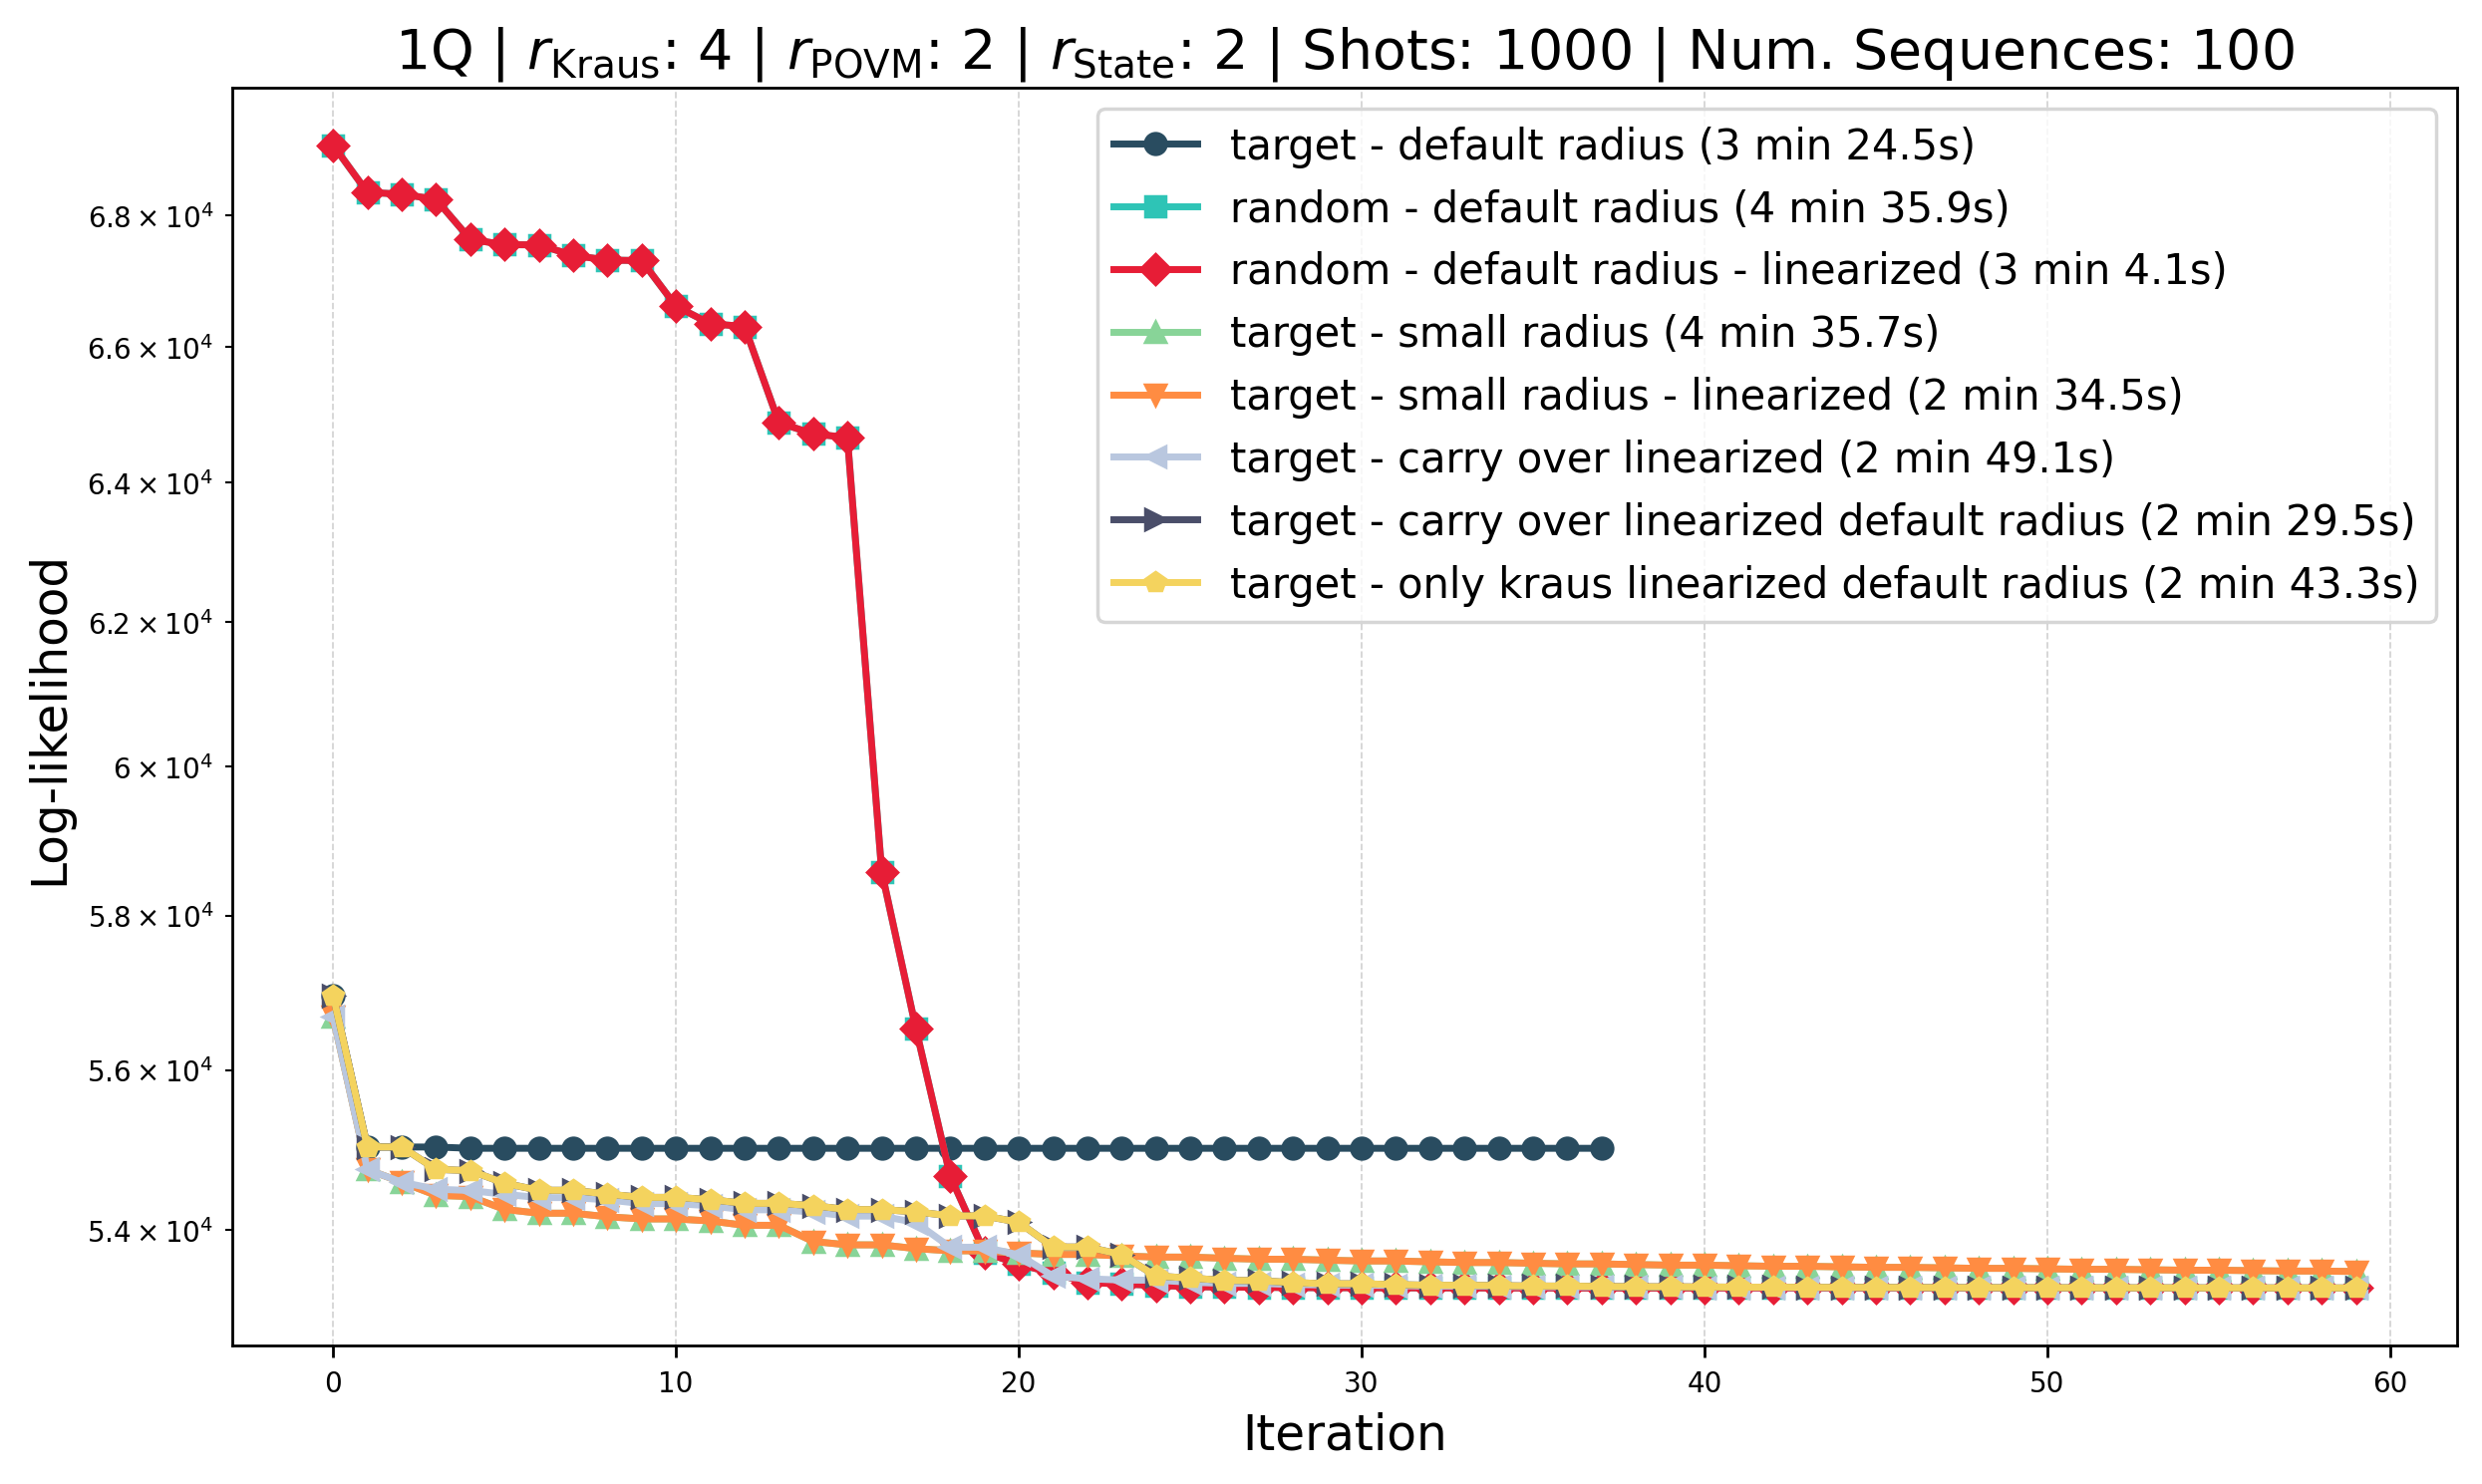

In [ ]:
title_init = rf"{num_qubits}Q | $r_\mathrm{{Kraus}}$: {kraus_rank} | $r_\mathrm{{POVM}}$: {povm_rank} | $r_\mathrm{{State}}$: {state_rank} | Shots: {shots} | Num. Sequences: {num_circuits_1q}"

cost_fns = [cost_fn_history_1q, cost_fn_history_1q_rnd, cost_fn_history_1q_rnd_linear, cost_fn_history_1q_small_radius, cost_fn_history_1q_small_radius_linear, cost_fn_history_1q_carry_over_linear, cost_fn_history_1q_carry_over_linear_og_radius, cost_fn_history_1q_only_kraus_linearized_og_radius] 

cost_fns_log_likelihood = [cost["main"] for cost in cost_fns]

labels = ["target - default radius (3 min 24.5s)", "random - default radius (4 min 35.9s)", "random - default radius - linearized (3 min 4.1s)", "target - small radius (4 min 35.7s)", "target - small radius - linearized (2 min 34.5s)", "target - small radius - linearized - carry over (2 min 49.1s)", "target - default radius - all linearized - carry over (2 min 29.5s)", "target - default radius - linearized - carry over (2 min 43.3s)"]

plot_cost_function(cost_fns_log_likelihood, title=title_init, labels=labels, ylabel="Log-likelihood") 

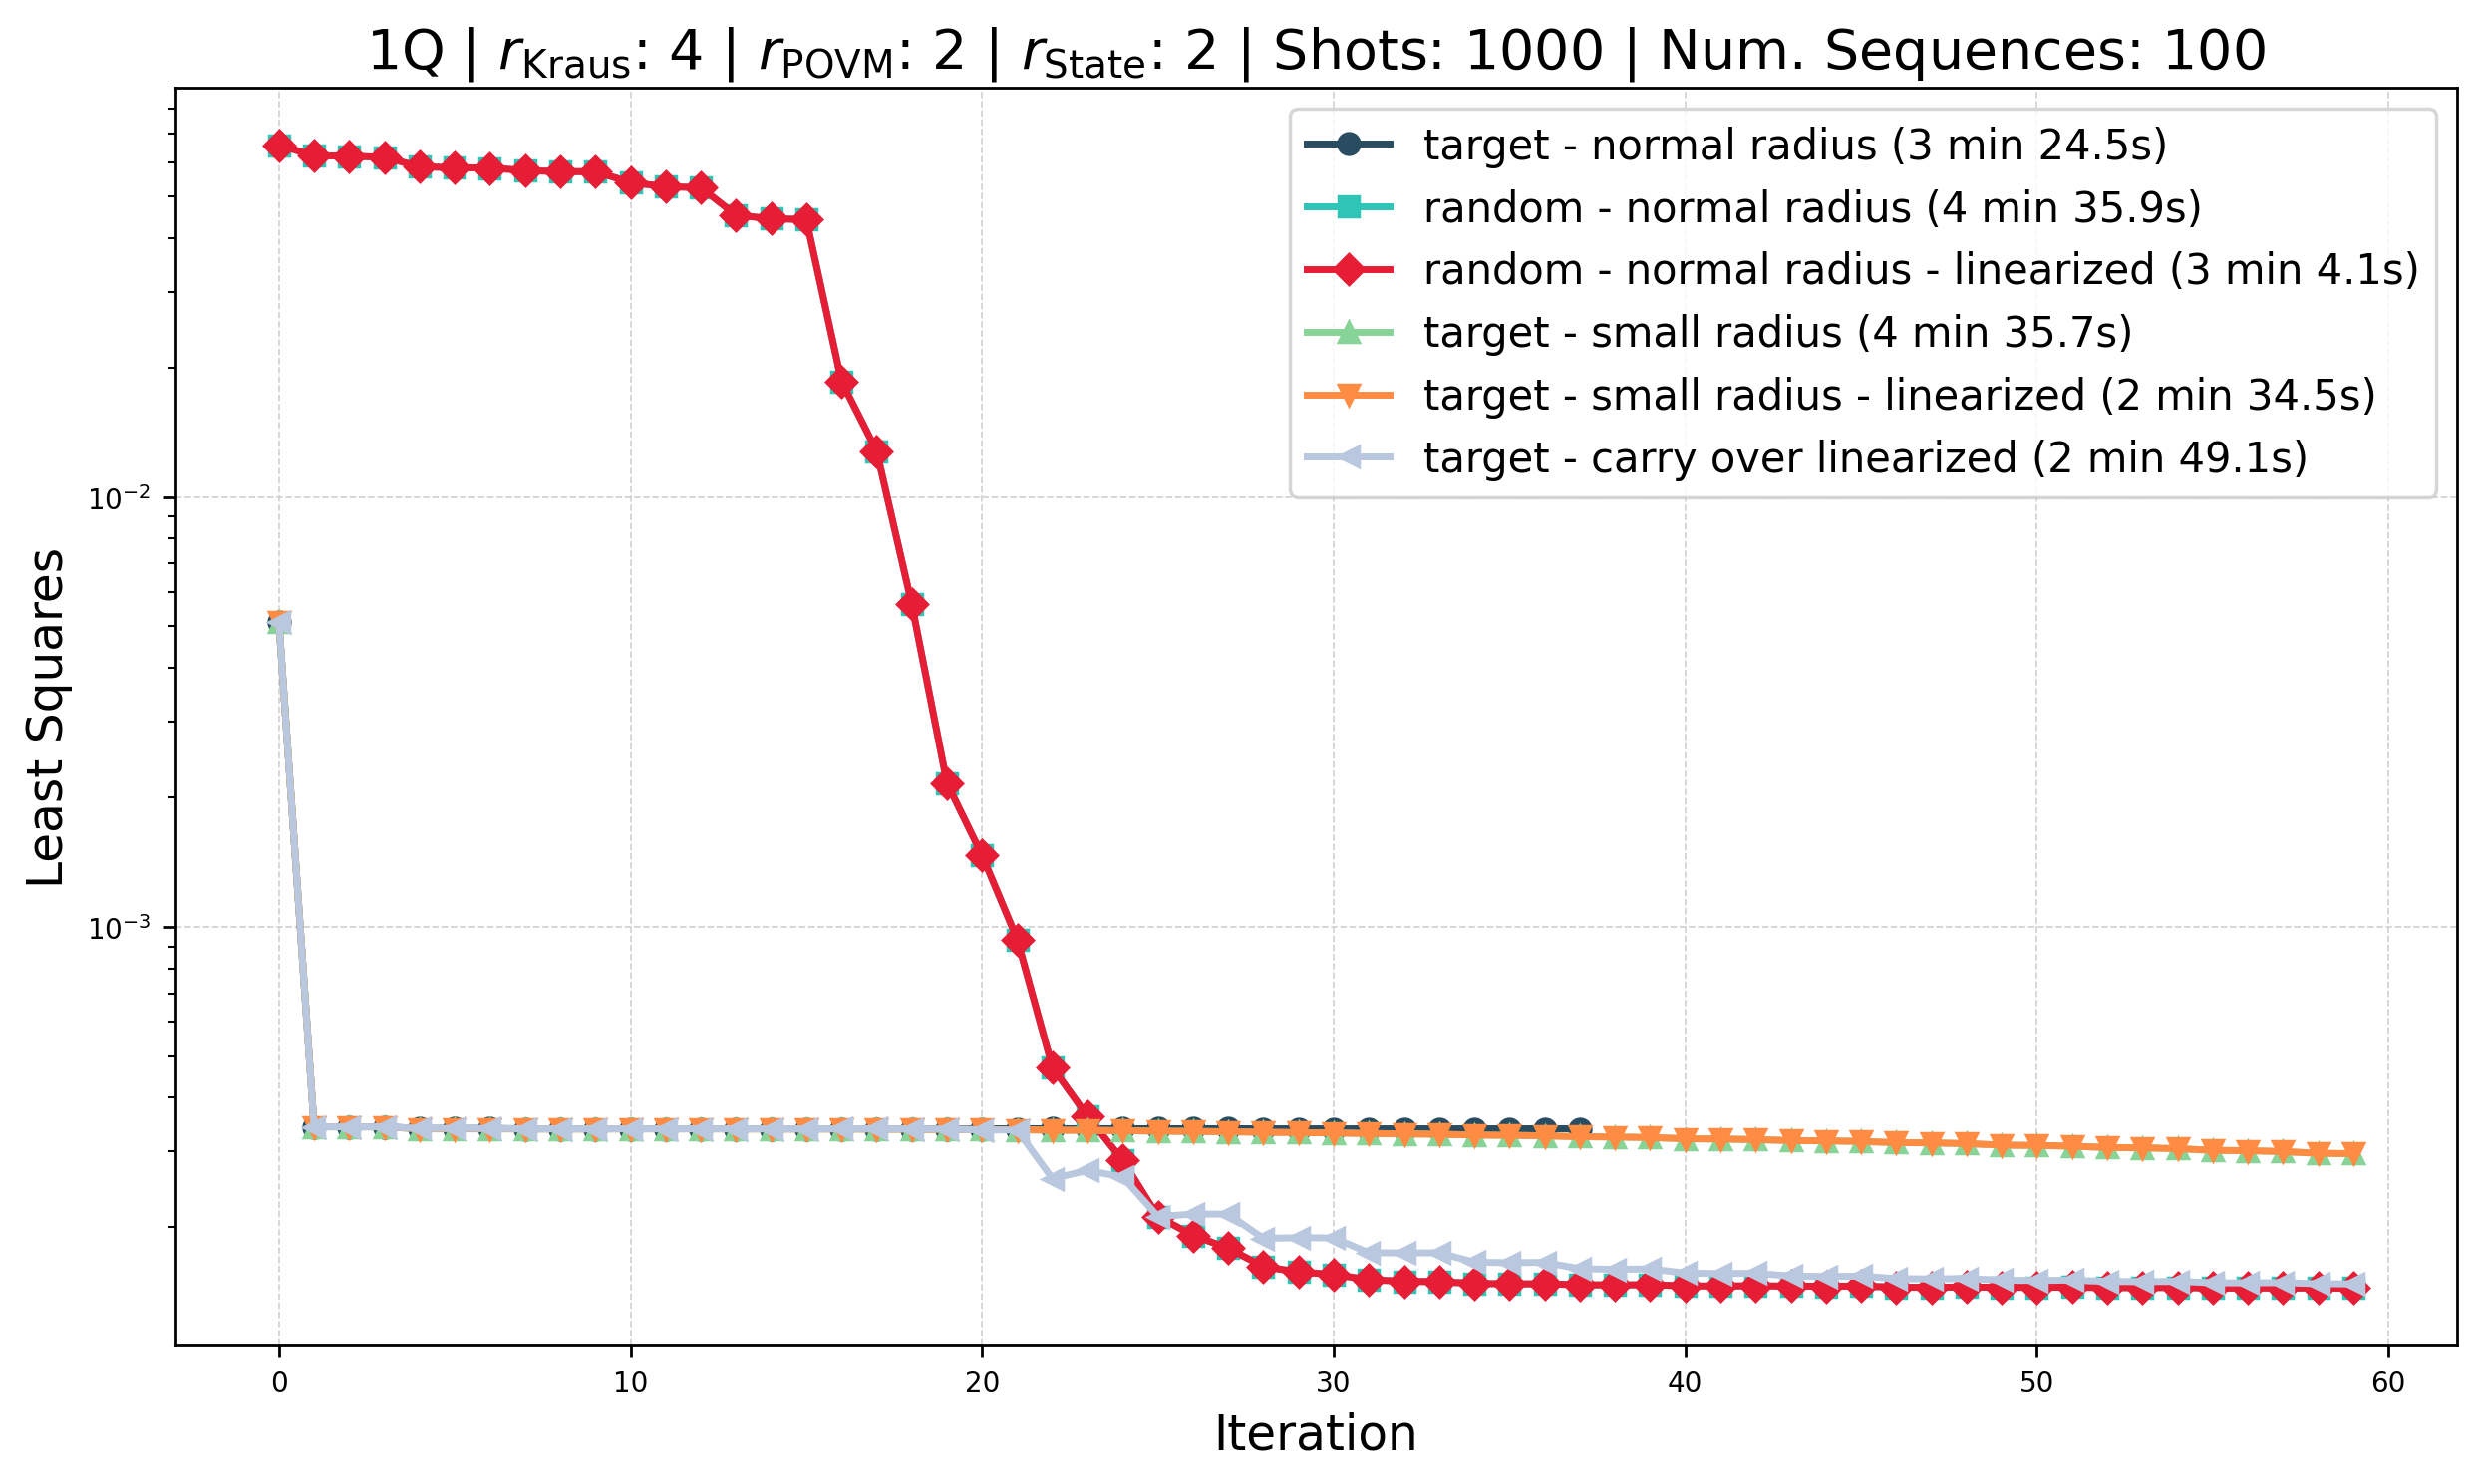

In [52]:
cost_fns_least_squares= [cost["least_squares"] for cost in cost_fns]
plot_cost_function(cost_fns_least_squares, title=title_init, labels=labels, ylabel="Least Squares")

# TODO:
It might be a good idea to re-use the optimization radius per operator between trust region iterations. As this carries information of the scale of each of the operators, and while the cost function changes due to the optimization on the other 2 operators, it should qualitatively remain similar.

# Conclusions:

1. Linearizing is a good idea, but it is highly dependent on the number of iterations needed in the truncated Conjugate Gradient (tCG). This is because linearizing the `hvp` is costly.

2. A quick investigation revealed the number of iterations both for 1Q and 3Q to make sense to linearize is around ~4-5 iterations. 

3. From this, we conclude that linearizing for the POVM and State almost makes no sense. This is also tightly connected to the fact that the POVM and State are so close to the actual target gate set (i.e., they are significantly less noisy than the Kraus operators), so the trust region radius for these operators is significantly smaller. In other words, the trust region steps should be more fine grained compared to the ones taken for the Kraus operator.

4. The result of this investigation is positive. As we can see from the plot, linearizing for the Kraus operator actually helps to decrease the optimization by almost 40% of the time.

5. Another interesting observation from this study is that starting with a random initialization with the right number of sequences is actually beneficial for the whole convergence. As we would expect, beyond the transition point, having the right number of sequences almost guarantees that every random initialization would converge. What I did not expect is that it would actually be better than initializing with the target gate set.
> TODO: This might require further investigation!

6. Lastly, this study showcases the importance of the trust region radius, which also prompts to mantaining a "memory" of the radius between successive trust region iterations among operators. Namely, the initial radius for the k-th outer iteration should be set from the previous iteration of that operator.